## Kmeans

In [61]:
import os
#最多只用 1 個 CPU 執行緒 去跑平行運算。
os.environ['OMP_NUM_THREADS'] = '1'

In [62]:
import numpy as np
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=150,
                 n_features=2,
                 centers=3,
                 cluster_std=0.5,
                 shuffle=True,
                 random_state=0)
# 150筆資料 2個特徵 分成3群 標準差0.5 是否重新洗牌shuffle

In [63]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3,init="k-means++",max_iter=300,random_state=0)

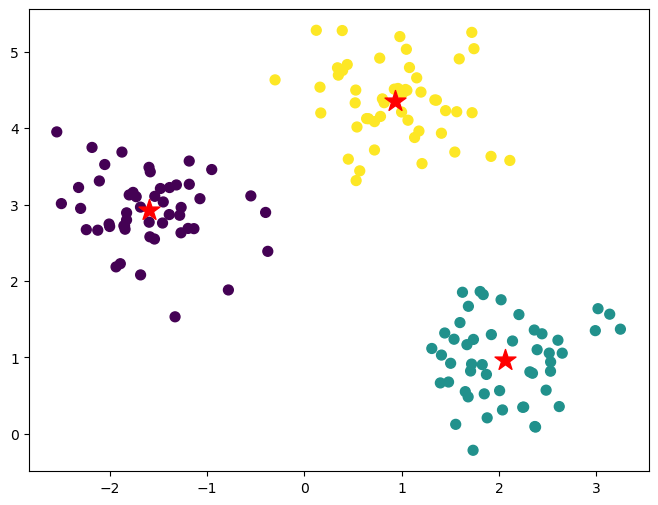

In [64]:
import matplotlib.pyplot as plt
y_km = km.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y_km,marker="o",s=50,cmap="viridis")
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],s=250,marker="*",c="red",label="centers")

In [65]:
km.inertia_
#km.inertia_ 所有點到它們所屬群中心的距離平方總和（Sum of Squared Distances, SSD）
#Inertia 越小越好

72.47601670996696

In [66]:
distortions = []
for i in range(1,11):
    km = KMeans(n_clusters=i,init="k-means++",max_iter=300,random_state=0)
    km.fit(X)
    distortions.append(km.inertia_)

for i in range(len(distortions)):
    print(i,distortions[i])

0 713.699828943416
1 283.461017802093
2 72.47601670996696
3 67.30934494757153
4 58.65546094894907
5 51.376481981954186
6 41.87680035829947
7 35.989883959510024
8 33.51421133964576
9 29.50793550053657


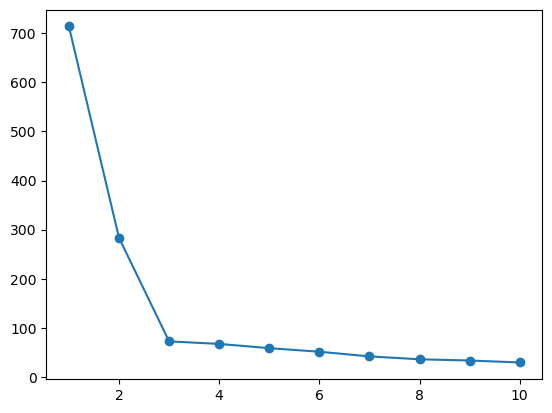

In [67]:
plt.plot(range(1,11),distortions,marker="o")

## silhouette_score 輪廓係數
它在看：同一群是不是夠近、不同群是不是夠遠

分數範圍：

-1 ~ 1

越接近 1 → 分群越好

接近 0 → 分群很模糊

負數 → 分得很爛


In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
#最多只用 1 個 CPU 執行緒 去跑平行運算。
os.environ['OMP_NUM_THREADS'] = '1'

In [69]:
import numpy as np
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=150, 
                  n_features=2, 
                  centers=3, 
                  cluster_std=0.5, 
                  shuffle=True, 
                  random_state=0)

In [70]:
scoreList = []
for k in range(2,10):
    km = KMeans(n_clusters=k,init="k-means++",max_iter=300,random_state=0)
    labes = km.fit_predict(X)
    score = silhouette_score(X,labes)
    scoreList.append((k,score))
#print(scoreList)
scoreList.sort(key=lambda x:x[1],reverse=True)
for k,s in scoreList:
    print(k,s)

3 0.7143417887288687
2 0.5848706144251782
4 0.5640802327362099
6 0.45769318506163664
5 0.4367927467614468
8 0.33747598854695504
9 0.3313319318964229
7 0.32656382253649174


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans

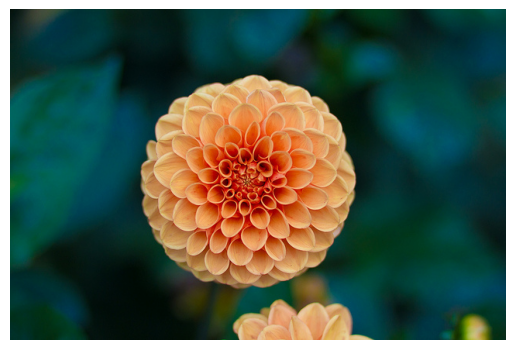

In [72]:
flower = load_sample_image("flower.jpg")
plt.axis("off")
plt.imshow(flower)

In [73]:
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# flower = mpimg.imread(r"C:\Users\xvpow\ai2_20251120\ch22\flower.jpg")#能讀所有圖

# plt.axis("off")
# plt.imshow(flower)
# plt.show()

## 正規化、取得圖片寬高及顏色維度、將寬高轉為一維

In [74]:
flower = np.array(flower,dtype=np.float64)/255
w,h,d = flower.shape
print(h,w,d)
image_array = np.reshape(flower,(h*w,d))
print(image_array.shape)

640 427 3
(273280, 3)


In [75]:
image_sample = shuffle(image_array,random_state=42)[:2000]


In [76]:
kmeans = KMeans(n_clusters=128,init="k-means++",random_state=42).fit(image_sample)

In [77]:
lables = kmeans.predict(image_array)

print(image_array.shape,lables.shape)

(273280, 3) (273280,)


In [78]:
#labels[labels_index] 群的id
#centers質心的位置 代表真的顏色
def reconstruct_image(centers,labels,w,h):
    d = centers.shape[1]
    image = np.zeros((w,h,d))
    labels_index = 0
    for i in range(w):
        for j in range(h):
            image[i][j] = centers[labels[labels_index]]
            labels_index += 1
    return image    

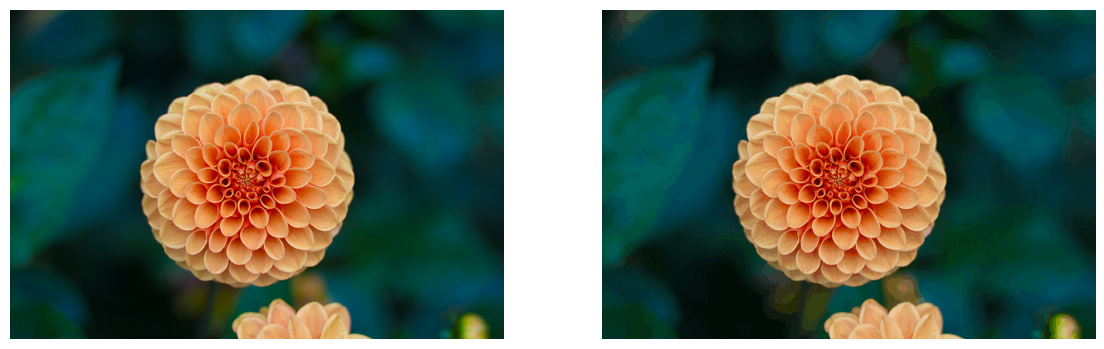

In [79]:
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.axis("off")
plt.imshow(flower)

plt.subplot(1,2,2)
plt.axis("off")
plt.imshow(reconstruct_image(kmeans.cluster_centers_,lables,w,h))

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

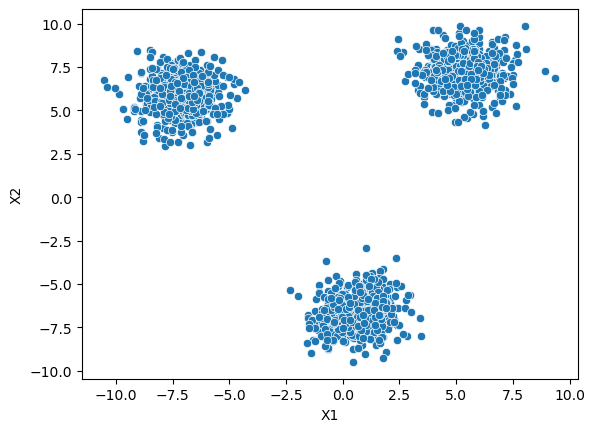

In [81]:
blobs = pd.read_csv("./cluster_blobs.csv")
blobs.head()
sns.scatterplot(x="X1",y="X2",data=blobs)
plt.show()

In [83]:
moons = pd.read_csv("./cluster_moons.csv")
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


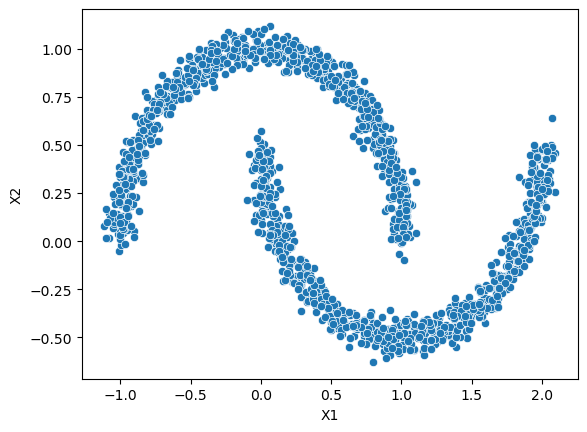

In [84]:
sns.scatterplot(x="X1",y="X2",data=moons)
plt.show()

In [85]:
circles = pd.read_csv("./cluster_circles.csv")
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


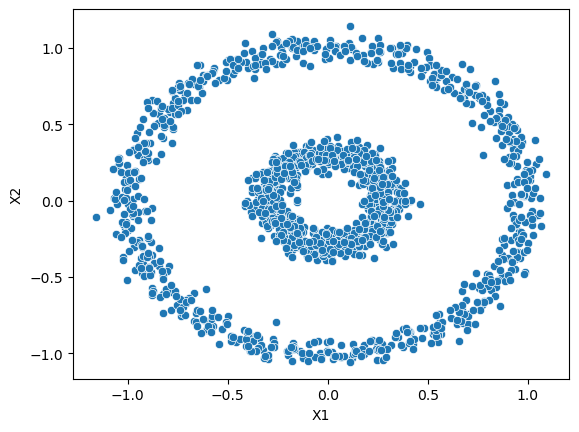

In [86]:
sns.scatterplot(x="X1",y="X2",data=circles)
plt.show()

## 用於顯示群集的散佈圖

In [ ]:
def display_mode(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(x="X1",y="X2",hue=labels,data=data,palette="Set1")
    plt.show()

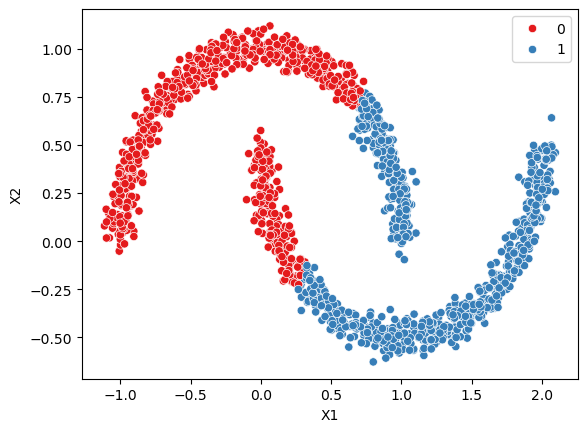

In [88]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, init='k-means++', n_init='auto')
display_mode(model,moons)

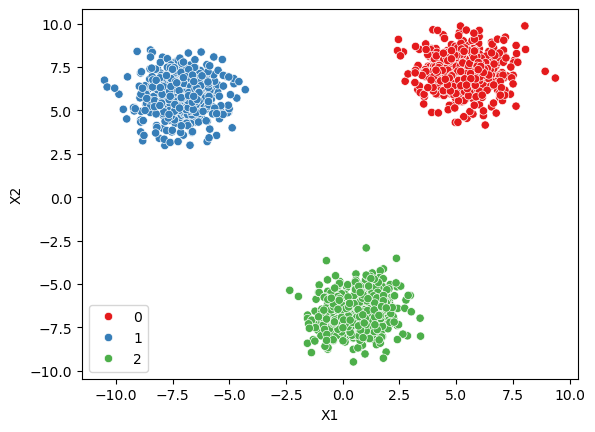

In [89]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, init='k-means++', n_init='auto')
display_mode(model,blobs)

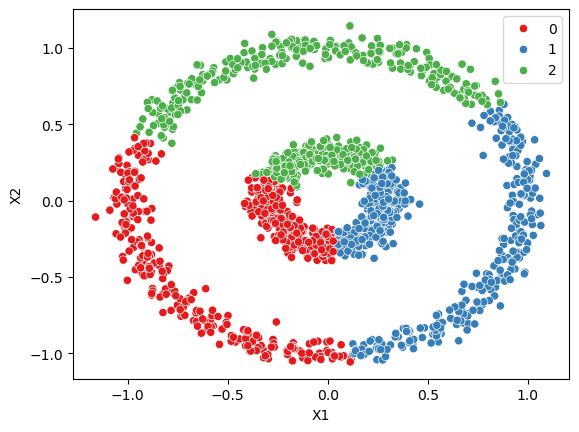

In [90]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, init='k-means++', n_init='auto')
display_mode(model,circles)

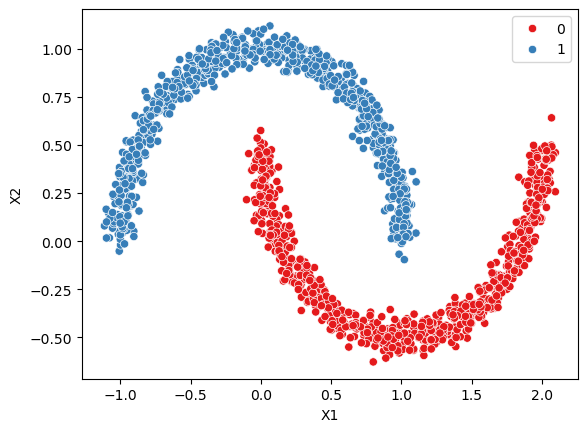

In [93]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps = 0.2)
display_mode(model,moons)

In [96]:
from sklearn.metrics import silhouette_score #輪廓係數
from sklearn.cluster import DBSCAN
import numpy as np
silhouette_scores = []
#silhouette_score 越大越好。
data = blobs
eps_values = np.arange(0.1,3.0,0.1)
for eps in eps_values:
    testModel = DBSCAN(eps= eps)
    y_km = testModel.fit_predict(data)
    if len(set(y_km)) > 1:#set過濾重複 至少要1個以上
        silhouette_scores.append(silhouette_score(data,y_km))
    else:
        silhouette_scores.append(-1) 

bast_index = np.argmax(silhouette_scores)        
bast_eps = eps_values[bast_index]
bast_score = silhouette_scores[bast_index]
print(f"eps:{bast_eps} bast_score:{bast_score}")

eps:1.5000000000000002 bast_score:0.8625486425630479


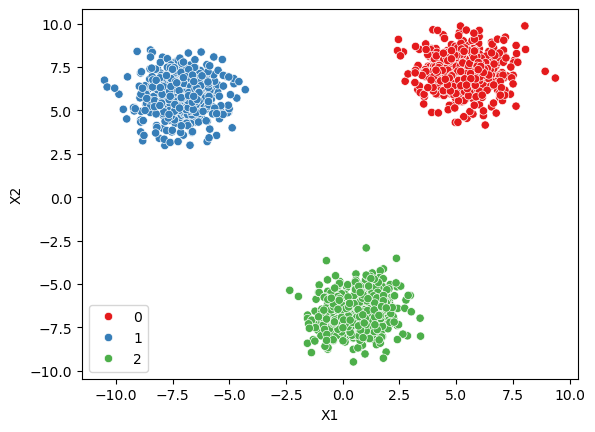

In [97]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps = 1.5)
display_mode(model,blobs)

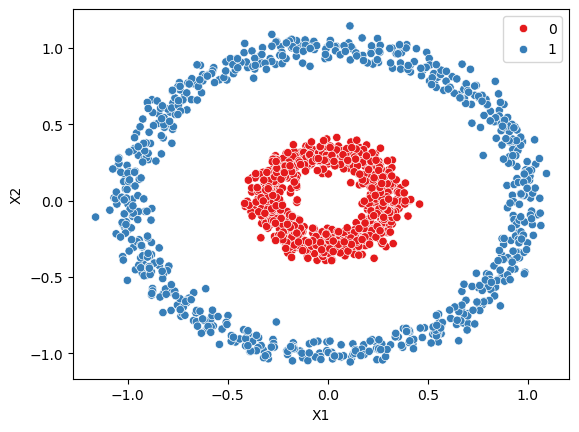

In [95]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps = 0.2)
display_mode(model,circles)

# 半監督式學習
# 自我訓練(Self-training)測試

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier

In [99]:
X,y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=0)

In [100]:
## 設定 約50% 資料為沒有標註(-1)
print(X_train.shape,y_train.shape)

rng = np.random.RandomState(42)
y_rand = rng.rand(y_train.shape[0])#均勻分布亂數
print(len(y_rand))

(120, 4) (120,)
120


In [101]:
y_50 = np.copy(y_train)
y_50[y_rand < 0.5] = -1#讓約50%的資料為-1為了移除標籤y
print(len(y_50[y_50==-1]))
print(len(y_train))

62
120


In [102]:
base_class = SVC(kernel="rbf",gamma=0.5)
base_class.fit(X_train,y_50)
base_class.score(X_test,y_test)

0.43333333333333335

In [103]:
base_class = SVC(kernel="rbf",gamma=0.5,probability=True)
#probability 預測的信心值（機率)
clf = SelfTrainingClassifier(base_class).fit(X_train,y_50)
clf.score(X_test,y_test)

1.0